In [2]:
import os
import numpy as np

folder = r"30yrs"   # path to your folder

# List all .grd files
grd_files = [f for f in os.listdir(folder) if f.endswith('.GRD')]

print("Number of files:", len(grd_files))
print("First few files:", grd_files[:5])

# Read the first file
file_path = os.path.join(folder, grd_files[0])

data = np.fromfile(file_path, dtype=np.float32)

print("File:", grd_files[0])
print("Total values:", len(data))
print("4485 blocks:", len(data)/4485)

Number of files: 31
First few files: ['Maxtemp_MaxT_1995.GRD', 'Maxtemp_MaxT_1996.GRD', 'Maxtemp_MaxT_1997.GRD', 'Maxtemp_MaxT_1998.GRD', 'Maxtemp_MaxT_1999.GRD']
File: Maxtemp_MaxT_1995.GRD
Total values: 350765
4485 blocks: 78.20847268673356


In [3]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

size = os.path.getsize(file_path)

print("File size (bytes):", size)
print("File size (MB):", size/1024/1024)

File size (bytes): 1403060
File size (MB): 1.3380622863769531


In [4]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

data = np.fromfile(file_path, dtype=np.float32)

daily_grids = data.reshape(365, 31, 31)

print(daily_grids.shape)

(365, 31, 31)


In [5]:
file_path = r"30yrs/Maxtemp_MaxT_1995.GRD"

data = np.fromfile(file_path, dtype=np.float32)

print("Total values:", len(data))

try:
    grid = data.reshape(365, 31, 31)
    print("Success:", grid.shape)
except Exception as e:
    print("Error:", e)

Total values: 350765
Success: (365, 31, 31)


In [6]:
print("Minimum:", np.min(grid))
print("Maximum:", np.max(grid))
print("First 10 values:")
print(grid[0,0,:10])

Minimum: 1.51
Maximum: 99.9
First 10 values:
[99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9]


In [7]:
import numpy as np

grid = np.where(grid == 99.9, np.nan, grid)

In [8]:
missing_count = np.isnan(grid).sum()
total_count = grid.size

print(f"Missing values: {missing_count}")
print(f"Percentage missing: {100*missing_count/total_count:.2f}%")

Missing values: 224374
Percentage missing: 63.97%


In [9]:
#CREATING NEW FOLDER FOR CLEANED DATA
import os

input_folder = "30yrs"
output_folder = "cleaned_data"

os.makedirs(output_folder, exist_ok=True)

In [10]:
for file in os.listdir(input_folder):

    if file.upper().endswith(".GRD"):

        file_path = os.path.join(input_folder, file)

        # Read data
        data = np.fromfile(file_path, dtype=np.float32)

        # Replace missing values
        data[data == 99.9] = np.nan

        # New filename
        new_name = file.replace(".GRD", "_cleaned.npy")

        output_path = os.path.join(output_folder, new_name)

        # Save cleaned file
        np.save(output_path, data)

        print(f"Saved: {new_name}")

print("All files cleaned successfully!")

Saved: Maxtemp_MaxT_1995_cleaned.npy
Saved: Maxtemp_MaxT_1996_cleaned.npy
Saved: Maxtemp_MaxT_1997_cleaned.npy
Saved: Maxtemp_MaxT_1998_cleaned.npy
Saved: Maxtemp_MaxT_1999_cleaned.npy
Saved: Maxtemp_MaxT_2000_cleaned.npy
Saved: Maxtemp_MaxT_2001_cleaned.npy
Saved: Maxtemp_MaxT_2002_cleaned.npy
Saved: Maxtemp_MaxT_2003_cleaned.npy
Saved: Maxtemp_MaxT_2004_cleaned.npy
Saved: Maxtemp_MaxT_2005_cleaned.npy
Saved: Maxtemp_MaxT_2006_cleaned.npy
Saved: Maxtemp_MaxT_2007_cleaned.npy
Saved: Maxtemp_MaxT_2008_cleaned.npy
Saved: Maxtemp_MaxT_2009_cleaned.npy
Saved: Maxtemp_MaxT_2010_cleaned.npy
Saved: Maxtemp_MaxT_2011_cleaned.npy
Saved: Maxtemp_MaxT_2012_cleaned.npy
Saved: Maxtemp_MaxT_2013_cleaned.npy
Saved: Maxtemp_MaxT_2014_cleaned.npy
Saved: Maxtemp_MaxT_2015_cleaned.npy
Saved: Maxtemp_MaxT_2016_cleaned.npy
Saved: Maxtemp_MaxT_2017_cleaned.npy
Saved: Maxtemp_MaxT_2018_cleaned.npy
Saved: Maxtemp_MaxT_2019_cleaned.npy
Saved: Maxtemp_MaxT_2020_cleaned.npy
Saved: Maxtemp_MaxT_2021_cleaned.npy
S

In [11]:
data = np.load(
    "cleaned_data/Maxtemp_MaxT_1995_cleaned.npy"
)

In [12]:
# Load cleaned file
data = np.load("cleaned_data/Maxtemp_MaxT_1995_cleaned.npy")

print("Shape:", data.shape)
print("Total values:", len(data))

print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))

print("NaN count:", np.isnan(data).sum())
print("Valid count:", np.sum(~np.isnan(data)))

Shape: (350765,)
Total values: 350765
Min: 1.51
Max: 47.6
NaN count: 224374
Valid count: 126391


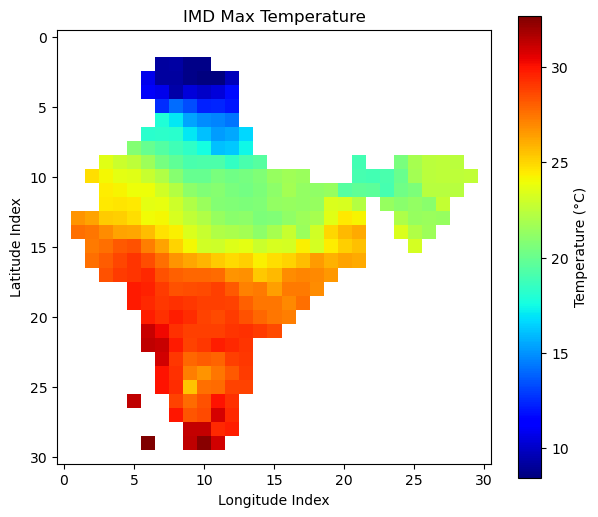

In [13]:
import numpy as np
import matplotlib.pyplot as plt

file = r"C:\Users\ASUS\Desktop\IMD\30yrs\Maxtemp_MaxT_1995.GRD"

# 1. Read binary data
data = np.fromfile(file, dtype=np.float32)

days = 365
rows = 31  
cols = 31  

# 2. Reshape to 3D matrix
data_3d = data.reshape((days, rows, cols))
day_1 = data_3d[0]

# 3. HORIZONTAL MIRROR ORIENTATION
# We apply a vertical matrix inversion (up-down) to reverse the horizontal axis presentation
mirrored_grid = np.flipud(day_1)

# 4. Remove background placeholder values
mirrored_grid = np.where(mirrored_grid >= 99.9, np.nan, mirrored_grid)

# 5. Render the map
plt.figure(figsize=(7, 6))
# Changing the origin to 'upper' flips the horizontal mapping plane relative to your image
plt.imshow(mirrored_grid, cmap='jet', origin='upper')
plt.colorbar(label='Temperature (°C)')

plt.title("IMD Max Temperature")
plt.xlabel("Longitude Index")
plt.ylabel("Latitude Index")
plt.show()

In [14]:
folder = "cleaned_data"

files = sorted([
    f for f in os.listdir(folder)
    if f.endswith(".npy")
])

print("Files:", len(files))
print(files[:3])

Files: 31
['Maxtemp_MaxT_1995_cleaned.npy', 'Maxtemp_MaxT_1996_cleaned.npy', 'Maxtemp_MaxT_1997_cleaned.npy']


In [15]:
points = {
"P1" : (20.319333, 85.460306),
"P2":(19.978167, 85.538667),
"P3": (20.050798, 86.012059),
"P4":(20.374472, 85.981694)}

In [16]:
import numpy as np
import math

file = r"C:\Users\ASUS\Desktop\IMD\30yrs\Maxtemp_MaxT_1995.GRD"

data = np.fromfile(file, dtype=np.float32)

n_values = len(data)

print("Total values:", n_values)

for days in [365, 366]:
    cells_per_day = n_values / days
    root = math.sqrt(cells_per_day)

    print(f"\nAssuming {days} days:")
    print("Cells/day =", cells_per_day)
    print("Grid size =", root)

Total values: 350765

Assuming 365 days:
Cells/day = 961.0
Grid size = 31.0

Assuming 366 days:
Cells/day = 958.3743169398907
Grid size = 30.95762130622911


In [17]:
import numpy as np

data = np.load(
    r"C:\Users\ASUS\Desktop\IMD\cleaned_data\Maxtemp_MaxT_1995_cleaned.npy"
)

data = data.reshape(365,31,31)

print(data.shape)

(365, 31, 31)


In [19]:
import numpy as np
import os
from glob import glob

folder = r"C:\Users\ASUS\Desktop\IMD\30yrs"

grd_files = glob(os.path.join(folder, "*.GRD"))

arr = np.fromfile(grd_files[0], dtype=np.float32)

print("Number of values:", len(arr))
print("File size:", os.path.getsize(grd_files[0]))
print("Min:", arr.min())
print("Max:", arr.max())

Number of values: 350765
File size: 1403060
Min: 1.51
Max: 99.9


In [20]:
import numpy as np

arr = np.fromfile(grd_files[0], dtype=np.float32)


print("Number of values:", len(arr))
print(arr[:20])

Number of values: 350765
[99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9 99.9
 99.9 99.9 99.9 99.9 99.9 99.9]


In [21]:
import numpy as np

arr = np.load(
    r"C:\Users\ASUS\Desktop\IMD\cleaned_data\Maxtemp_MaxT_1995_cleaned.npy"
)

print(arr.shape)

(350765,)


In [22]:
import numpy as np

lats = np.arange(37.5, 6.5, -1.0)  # 7.5 to 37.5
lons = np.arange(67.5, 98.5, 1.0)  # 67.5 to 97.5

print(len(lats), len(lons))

31 31


In [23]:
import geopandas as gpd
from shapely.geometry import Point

points = []

for lat in lats:
    for lon in lons:
        points.append(Point(lon, lat))

gdf = gpd.GeoDataFrame(
    geometry=points,
    crs="EPSG:4326"
)

print(gdf.head())

            geometry
0  POINT (67.5 37.5)
1  POINT (68.5 37.5)
2  POINT (69.5 37.5)
3  POINT (70.5 37.5)
4  POINT (71.5 37.5)


In [24]:
records = []

for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):

        records.append({
            "row": i,
            "col": j,
            "lat": lat,
            "lon": lon,
            "geometry": Point(lon, lat)
        })

grid_gdf = gpd.GeoDataFrame(
    records,
    crs="EPSG:4326"
)

grid_gdf.head()

,row,col,lat,lon,geometry
0,0,0,37.5,67.5,POINT (67.5 37.5)
1,0,1,37.5,68.5,POINT (68.5 37.5)
2,0,2,37.5,69.5,POINT (69.5 37.5)
3,0,3,37.5,70.5,POINT (70.5 37.5)
4,0,4,37.5,71.5,POINT (71.5 37.5)


In [27]:
districts = gpd.read_file("Odisha.shp")

print(districts.crs)

EPSG:4326


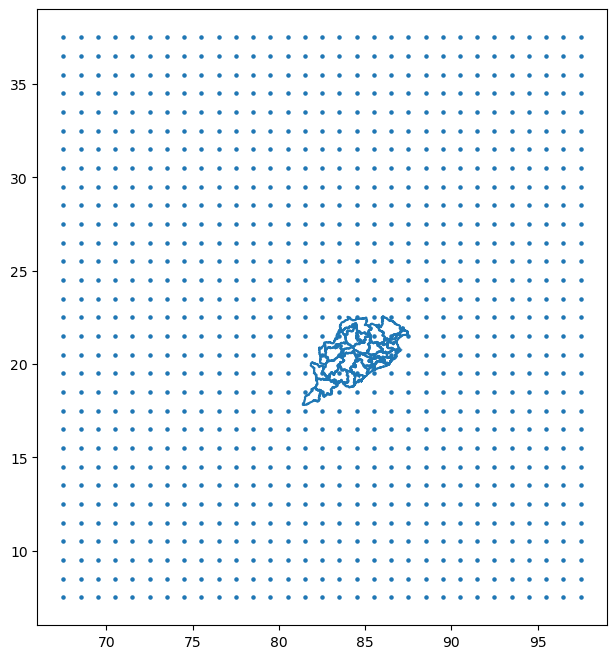

In [28]:
#TO SHOW THAT GRID OVERLAPS ODISHA
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

districts.boundary.plot(ax=ax)
grid_gdf.plot(ax=ax, markersize=5)

plt.show()

In [29]:
odisha_points = gpd.sjoin(
    grid_gdf,
    districts,
    predicate="within"
)

print(len(odisha_points))
odisha_points.head()

12


,row,col,lat,lon,geometry,index_right,ID_0,ISO,NAME_0,ID_1,...,ID_2,NAME_2,ID_3,NAME_3,NL_NAME_3,VARNAME_3,TYPE_3,ENGTYPE_3,ANU,X
512,16,16,21.5,83.5,POINT (83.5 21.5),18,105,IND,India,26,...,374,Baragarh,1525,Bargarh,None,None,Taluk,Taluk,None,83.346
513,16,17,21.5,84.5,POINT (84.5 21.5),2,105,IND,India,26,...,379,Deogarh,1535,Deogarh,None,None,Taluk,Taluk,None,84.797
514,16,18,21.5,85.5,POINT (85.5 21.5),26,105,IND,India,26,...,389,Keonjhar,1551,Anandapur,None,None,Taluk,Taluk,None,85.699
515,16,19,21.5,86.5,POINT (86.5 21.5),24,105,IND,India,26,...,393,Mayurbhanj,1559,Baripada,None,None,Taluk,Taluk,None,86.406
542,17,15,20.5,82.5,POINT (82.5 20.5),11,105,IND,India,26,...,396,Nuapada,1565,Nuaparha,None,None,Taluk,Taluk,None,82.571


In [30]:
print(odisha_points.columns)

Index(['row', 'col', 'lat', 'lon', 'geometry', 'index_right', 'ID_0', 'ISO',
       'NAME_0', 'ID_1', 'NAME_1', 'ID_2', 'NAME_2', 'ID_3', 'NAME_3',
       'NL_NAME_3', 'VARNAME_3', 'TYPE_3', 'ENGTYPE_3', 'ANU', 'X'],
      dtype='object')


In [31]:
odisha_points[['lat','lon']].head()

,lat,lon
512,21.5,83.5
513,21.5,84.5
514,21.5,85.5
515,21.5,86.5
542,20.5,82.5


In [32]:
print(odisha_points["NAME_3"].unique())
print(odisha_points["NAME_3"].nunique())

['Bargarh' 'Deogarh' 'Anandapur' 'Baripada' 'Nuaparha' 'Patnagarh' 'Bauda'
 'Athagarh' 'Kendraparha' 'Nabarangapur' 'Gunupur' 'Brahmapur']
12


In [33]:
print(len(odisha_points))


12


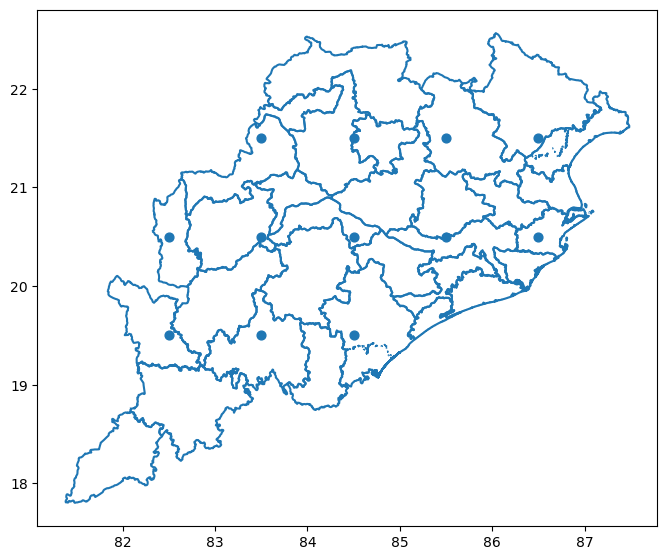

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

districts.boundary.plot(ax=ax)
odisha_points.plot(ax=ax, markersize=40)

plt.show()

In [35]:
print(districts["NAME_3"].nunique())

31


In [37]:
print("NAME_1:", districts["NAME_1"].unique()[:10])
print("NAME_2:", districts["NAME_2"].unique()[:10])
print("NAME_3:", districts["NAME_3"].unique()[:10])

NAME_1: ['Orissa']
NAME_2: ['Bhadrak' 'Boudh' 'Deogarh' 'Gajapati' 'Jagatsinghpur' 'Jajpur'
 'Jharsuguda' 'Kendrapara' 'Malkangiri' 'Nabarangpur']
NAME_3: ['Bhadrak' 'Bauda' 'Deogarh' 'Paralakhemundi' 'Jagatsinghpur' 'Jajapur'
 'Jharsuguda' 'Kendraparha' 'Malakanagiri' 'Nabarangapur']


In [38]:
print(districts[["NAME_1","NAME_2","NAME_3"]].head(20))

    NAME_1         NAME_2          NAME_3
0   Orissa        Bhadrak         Bhadrak
1   Orissa          Boudh           Bauda
2   Orissa        Deogarh         Deogarh
3   Orissa       Gajapati  Paralakhemundi
4   Orissa  Jagatsinghpur   Jagatsinghpur
5   Orissa         Jajpur         Jajapur
6   Orissa     Jharsuguda      Jharsuguda
7   Orissa     Kendrapara     Kendraparha
8   Orissa     Malkangiri    Malakanagiri
9   Orissa    Nabarangpur    Nabarangapur
10  Orissa       Nayagarh        Nayagarh
11  Orissa        Nuapada        Nuaparha
12  Orissa           Puri    n.a. ( 1507)
13  Orissa           Puri            Puri
14  Orissa        Sonepur         Sonapur
15  Orissa        Koraput          Jaypur
16  Orissa      Kalahandi    Bhawanipatna
17  Orissa       Rayagada         Gunupur
18  Orissa       Baragarh         Bargarh
19  Orissa       Bolangir       Patnagarh


In [39]:
print(sorted(districts["NAME_2"].unique()))

['Angul', 'Baleshwar', 'Baragarh', 'Bhadrak', 'Bolangir', 'Boudh', 'Cuttack', 'Deogarh', 'Dhenkanal', 'Gajapati', 'Ganjam', 'Jagatsinghpur', 'Jajpur', 'Jharsuguda', 'Kalahandi', 'Kandhamal', 'Kendrapara', 'Keonjhar', 'Khordha', 'Koraput', 'Malkangiri', 'Mayurbhanj', 'Nabarangpur', 'Nayagarh', 'Nuapada', 'Puri', 'Rayagada', 'Sambalpur', 'Sonepur', 'Sundargarh']


In [40]:
target = ["Cuttack", "Jagatsinghpur", "Kendrapara"]

selected = districts[districts["NAME_2"].isin(target)]

print(selected[["NAME_2"]].drop_duplicates())

           NAME_2
4   Jagatsinghpur
7      Kendrapara
23        Cuttack


In [43]:
selected = districts[
    districts["NAME_2"].isin(
        ["Cuttack", "Kendrapara", "Jagatsinghpur"]
    )
].copy()

print(selected["NAME_2"])

4     Jagatsinghpur
7        Kendrapara
23          Cuttack
Name: NAME_2, dtype: object


In [44]:
#FIND 4 NEAREST IMD GRID POINTS
grid_proj = grid_gdf.to_crs(3857)
selected_proj = selected.to_crs(3857)

In [45]:
nearest_points = {}

for idx, district in selected_proj.iterrows():

    district_name = district["NAME_2"]

    centroid = district.geometry.centroid

    temp_grid = grid_proj.copy()

    temp_grid["distance"] = temp_grid.distance(centroid)

    nearest4 = temp_grid.nsmallest(4, "distance")

    nearest_points[district_name] = nearest4

    print(f"\n{district_name}")
    print(nearest4[["row", "col", "lat", "lon", "distance"]])


Jagatsinghpur
     row  col   lat   lon       distance
546   17   19  20.5  86.5   38628.614222
577   18   19  19.5  86.5   86879.913666
545   17   18  20.5  85.5   98335.459271
576   18   18  19.5  85.5  125402.600100

Kendrapara
     row  col   lat   lon       distance
546   17   19  20.5  86.5   12930.647218
547   17   20  20.5  87.5   99816.970466
515   16   19  21.5  86.5  114246.381586
545   17   18  20.5  85.5  123105.782735

Cuttack
     row  col   lat   lon       distance
545   17   18  20.5  85.5   23085.704551
546   17   19  20.5  86.5   89471.954311
576   18   18  19.5  85.5  113946.486310
514   16   18  21.5  85.5  127847.765106


In [54]:
# A FUNCTION TO CALCULATE DISTRICT TMAX USING IDW 
import numpy as np

def idw_district_tmax(arr, points):

    temps = []
    weights = []

    for row, col, dist in points:

        temps.append(arr[:, row, col])

        weights.append(1/(dist**2))

    temps = np.array(temps)

    weights = np.array(weights)

    district_tmax = np.average(
        temps,
        axis=0,
        weights=weights
    )

    return district_tmax

In [55]:
jag_points = [
    (17,19,38628.614222),
    (18,19,86879.913666),
    (17,18,98335.459271),
    (18,18,125402.600100)
]

In [56]:
ken_points = [
    (17,19,12930.647218),
    (17,20,99816.970466),
    (16,19,114246.381586),
    (17,18,123105.782735)
]

In [53]:
cut_points = [
    (17,18,23085.704551),
    (17,19,89471.954311),
    (18,18,113946.486310),
    (16,18,127847.765106)
]

In [57]:
arr = np.load(
    r"C:\Users\ASUS\Desktop\IMD\cleaned_data\Maxtemp_MaxT_1995_cleaned.npy"
)

arr = arr.reshape(365,31,31)

cuttack_1995 = idw_district_tmax(arr, cut_points)

print(cuttack_1995.shape)
print(cuttack_1995[:10])

(365,)
[21.97502963 22.00302448 22.86998142 23.86874052 24.15417759 22.86309688
 22.83464685 23.52106991 19.92362434 18.91247796]


In [58]:
import os
import re
import numpy as np
import pandas as pd
from glob import glob

folder = r"C:\Users\ASUS\Desktop\IMD\cleaned_data"

files = sorted(glob(os.path.join(folder, "*.npy")))

all_data = []

for file in files:

    year = int(re.search(r'(\d{4})', os.path.basename(file)).group(1))

    arr = np.load(file)

    # Handle leap years automatically
    n_days = len(arr) // (31 * 31)

    arr = arr.reshape(n_days, 31, 31)

    cuttack_tmax = idw_district_tmax(arr, cut_points)

    dates = pd.date_range(
        start=f"{year}-01-01",
        periods=n_days,
        freq="D"
    )

    df_year = pd.DataFrame({
        "Date": dates,
        "District": "Cuttack",
        "Tmax": cuttack_tmax
    })

    all_data.append(df_year)

    print(f"Processed {year}")

cuttack_df = pd.concat(all_data, ignore_index=True)

print(cuttack_df.head())
print(cuttack_df.tail())
print("Total days:", len(cuttack_df))

Processed 1995
Processed 1996
Processed 1997
Processed 1998
Processed 1999
Processed 2000
Processed 2001
Processed 2002
Processed 2003
Processed 2004
Processed 2005
Processed 2006
Processed 2007
Processed 2008
Processed 2009
Processed 2010
Processed 2011
Processed 2012
Processed 2013
Processed 2014
Processed 2015
Processed 2016
Processed 2017
Processed 2018
Processed 2019
Processed 2020
Processed 2021
Processed 2022
Processed 2023
Processed 2024
Processed 2025
        Date District       Tmax
0 1995-01-01  Cuttack  21.975030
1 1995-01-02  Cuttack  22.003024
2 1995-01-03  Cuttack  22.869981
3 1995-01-04  Cuttack  23.868741
4 1995-01-05  Cuttack  24.154178
            Date District       Tmax
11318 2025-12-27  Cuttack  19.363636
11319 2025-12-28  Cuttack  18.628744
11320 2025-12-29  Cuttack  17.663995
11321 2025-12-30  Cuttack  17.899241
11322 2025-12-31  Cuttack  20.281448
Total days: 11323


In [59]:
output_file = r"C:\Users\ASUS\Desktop\IMD\Cuttack_daily_tmax_1995_2024.csv"

cuttack_df.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: C:\Users\ASUS\Desktop\IMD\Cuttack_daily_tmax_1995_2024.csv


In [60]:
import os
import re
import numpy as np
import pandas as pd
from glob import glob

folder = r"C:\Users\ASUS\Desktop\IMD\cleaned_data"

files = sorted(glob(os.path.join(folder, "*.npy")))

all_data = []

for file in files:

    year = int(re.search(r'(\d{4})', os.path.basename(file)).group(1))

    arr = np.load(file)

    n_days = len(arr) // (31 * 31)

    arr = arr.reshape(n_days, 31, 31)

    kendrapara_tmax = idw_district_tmax(arr, ken_points)

    dates = pd.date_range(
        start=f"{year}-01-01",
        periods=n_days,
        freq="D"
    )

    df_year = pd.DataFrame({
        "Date": dates,
        "District": "Kendrapara",
        "Tmax": kendrapara_tmax
    })

    all_data.append(df_year)

    print(f"Processed {year}")

kendrapara_df = pd.concat(all_data, ignore_index=True)

print(kendrapara_df.head())
print(kendrapara_df.tail())
print("Total days:", len(kendrapara_df))

Processed 1995
Processed 1996
Processed 1997
Processed 1998
Processed 1999
Processed 2000
Processed 2001
Processed 2002
Processed 2003
Processed 2004
Processed 2005
Processed 2006
Processed 2007
Processed 2008
Processed 2009
Processed 2010
Processed 2011
Processed 2012
Processed 2013
Processed 2014
Processed 2015
Processed 2016
Processed 2017
Processed 2018
Processed 2019
Processed 2020
Processed 2021
Processed 2022
Processed 2023
Processed 2024
Processed 2025
        Date    District       Tmax
0 1995-01-01  Kendrapara  23.536101
1 1995-01-02  Kendrapara  23.310878
2 1995-01-03  Kendrapara  23.359878
3 1995-01-04  Kendrapara  23.991700
4 1995-01-05  Kendrapara  24.607068
            Date    District       Tmax
11318 2025-12-27  Kendrapara  19.254626
11319 2025-12-28  Kendrapara  19.526307
11320 2025-12-29  Kendrapara  17.268367
11321 2025-12-30  Kendrapara  17.142542
11322 2025-12-31  Kendrapara  19.068529
Total days: 11323


In [61]:
output_file = r"C:\Users\ASUS\Desktop\IMD\Kendrapara_daily_tmax_1995_2025.csv"

kendrapara_df.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: C:\Users\ASUS\Desktop\IMD\Kendrapara_daily_tmax_1995_2025.csv


In [62]:
import os
import re
import numpy as np
import pandas as pd
from glob import glob

folder = r"C:\Users\ASUS\Desktop\IMD\cleaned_data"

files = sorted(glob(os.path.join(folder, "*.npy")))

all_data = []

for file in files:

    year = int(re.search(r'(\d{4})', os.path.basename(file)).group(1))

    arr = np.load(file)

    n_days = len(arr) // (31 * 31)

    arr = arr.reshape(n_days, 31, 31)

    jagatsinghpur_tmax = idw_district_tmax(arr, jag_points)

    dates = pd.date_range(
        start=f"{year}-01-01",
        periods=n_days,
        freq="D"
    )

    df_year = pd.DataFrame({
        "Date": dates,
        "District": "Jagatsinghpur",
        "Tmax": jagatsinghpur_tmax
    })

    all_data.append(df_year)

    print(f"Processed {year}")

jagatsinghpur_df = pd.concat(all_data, ignore_index=True)

print(jagatsinghpur_df.head())
print(jagatsinghpur_df.tail())
print("Total days:", len(jagatsinghpur_df))

Processed 1995
Processed 1996
Processed 1997
Processed 1998
Processed 1999
Processed 2000
Processed 2001
Processed 2002
Processed 2003
Processed 2004
Processed 2005
Processed 2006
Processed 2007
Processed 2008
Processed 2009
Processed 2010
Processed 2011
Processed 2012
Processed 2013
Processed 2014
Processed 2015
Processed 2016
Processed 2017
Processed 2018
Processed 2019
Processed 2020
Processed 2021
Processed 2022
Processed 2023
Processed 2024
Processed 2025
        Date       District       Tmax
0 1995-01-01  Jagatsinghpur  23.178736
1 1995-01-02  Jagatsinghpur  22.968124
2 1995-01-03  Jagatsinghpur  23.157967
3 1995-01-04  Jagatsinghpur  23.823357
4 1995-01-05  Jagatsinghpur  24.366352
            Date       District       Tmax
11318 2025-12-27  Jagatsinghpur  18.925430
11319 2025-12-28  Jagatsinghpur  18.980678
11320 2025-12-29  Jagatsinghpur  16.992109
11321 2025-12-30  Jagatsinghpur  16.971411
11322 2025-12-31  Jagatsinghpur  19.104893
Total days: 11323


In [63]:
output_file = r"C:\Users\ASUS\Desktop\IMD\Jagatsinghpur_daily_tmax_1995_2025.csv"

jagatsinghpur_df.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: C:\Users\ASUS\Desktop\IMD\Jagatsinghpur_daily_tmax_1995_2025.csv


In [64]:
import numpy as np

arr = np.load(
    r"C:\Users\ASUS\Desktop\IMD\cleaned_data\Maxtemp_MaxT_1995_cleaned.npy"
)

print(arr.shape)
print(np.nanmin(arr))
print(np.nanmax(arr))

(350765,)
1.51
47.6
